# Proyecto Final
 


Objetivo: revisar la relacion entre la cantidad de horas que un adolecente pasa en redes sociales, durante el dia y antes de dormir, vs la ansiedad y el estres

In [2]:
# Paso 0: Importación de librerías esenciales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN

In [3]:
#Cargar el dataset 

data = pd.read_csv("Teen_Mental_Health_Dataset.csv")

# Revisar los datos

data.info()


<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   str    
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   str    
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   str    
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), str(3)
memory usage: 122.0 KB


In [4]:
#Eliminar columnas

columnas_a_eliminar =['gender','platform_usage','age','social_interaction_level']
data_limpia = data.drop(columns=columnas_a_eliminar, errors='ignore')

data_limpia


,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
0,7.9,7.4,2.9,3.01,1.5,2,2,1,0
1,1.9,8.0,2.9,3.22,0.8,8,1,10,0
2,1.3,7.6,0.5,3.92,0.0,2,4,2,0
3,7.4,6.9,1.6,3.48,0.8,1,7,9,0
4,4.7,4.9,3.0,2.37,1.4,3,5,2,0
...,...,...,...,...,...,...,...,...,...
1195,6.8,6.6,2.0,2.76,1.0,3,4,4,0
1196,2.3,8.0,1.9,2.12,0.4,7,4,4,0
1197,1.7,8.7,0.7,3.98,0.8,1,1,1,0
1198,3.9,8.5,2.1,3.19,0.6,7,9,9,0


In [5]:
# Escalamiento de datos
StandardScaler = StandardScaler()
data_scaled = StandardScaler.fit_transform(data_limpia)

In [6]:
# Reduccion de la dimensionalidad

pca = PCA(n_components=2)
data_pca = pca.fit_transform(data_scaled)

In [7]:
pca.explained_variance_ratio_
pca.explained_variance_ratio_.sum()
pca.components_

array([[ 0.36619959, -0.37590203, -0.01267128, -0.06727695, -0.03051605,
         0.35537115,  0.36760023,  0.0268982 ,  0.67589603],
       [ 0.20111378,  0.03717072, -0.32691991,  0.6385295 ,  0.50346124,
         0.23753281, -0.35810716,  0.04283187,  0.06003897]])

Text(0, 0.5, 'Componente principal 2')

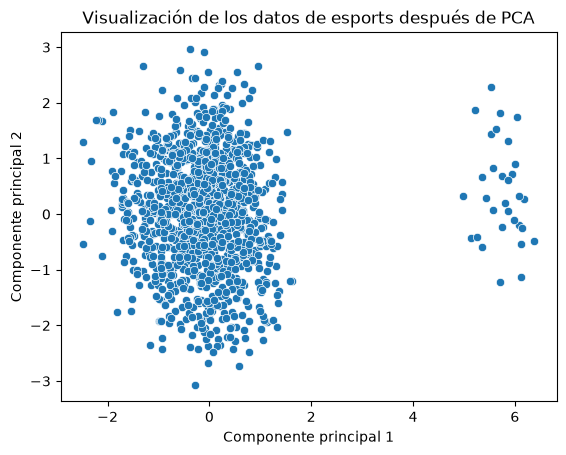

In [8]:
sns.scatterplot(x=data_pca[:, 0], y=data_pca[:, 1])
plt.title("Visualización de los datos de esports después de PCA")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")

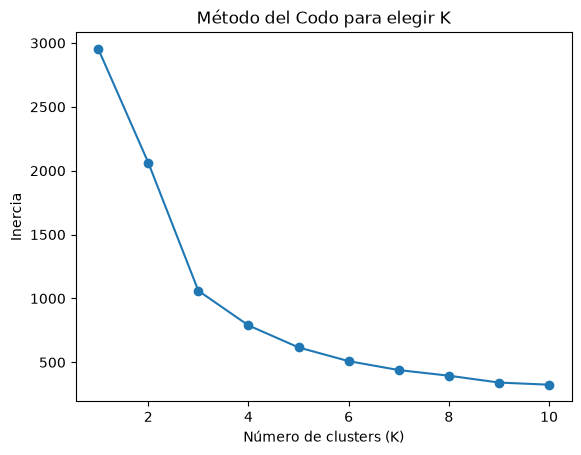

In [9]:
# Metodo del Codo

inertias = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(data_pca)
    inertias.append(km.inertia_)

plt.plot(k_range, inertias, marker='o')
plt.title('Método del Codo para elegir K')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Inercia')
plt.show()

Text(0, 0.5, 'Componente principal 2')

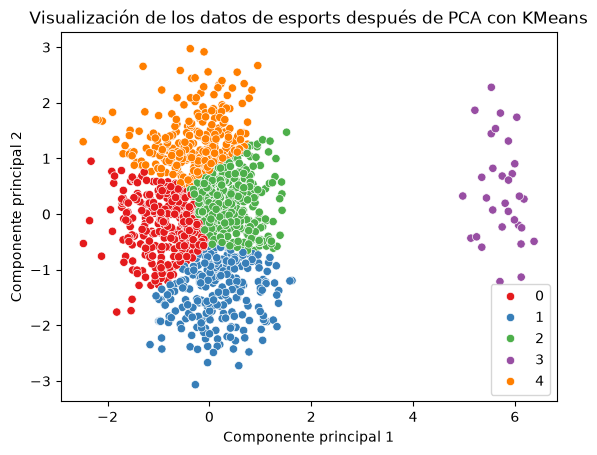

In [10]:
# Metodo de KMeans

kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(data_pca)

sns.scatterplot(x=data_pca[:, 0], y=data_pca[:, 1], hue=kmeans.labels_, palette='Set1')
plt.title("Visualización de los datos de esports después de PCA con KMeans")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")

In [11]:
Clusters = pd.DataFrame(kmeans.labels_,columns=['Cluster'])
data_clusters = data.merge(Clusters,left_index=True,right_index=True)

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_1100\2870835353.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_1100\2870835353.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_1100\2870835353.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_1100\2870835353.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable t

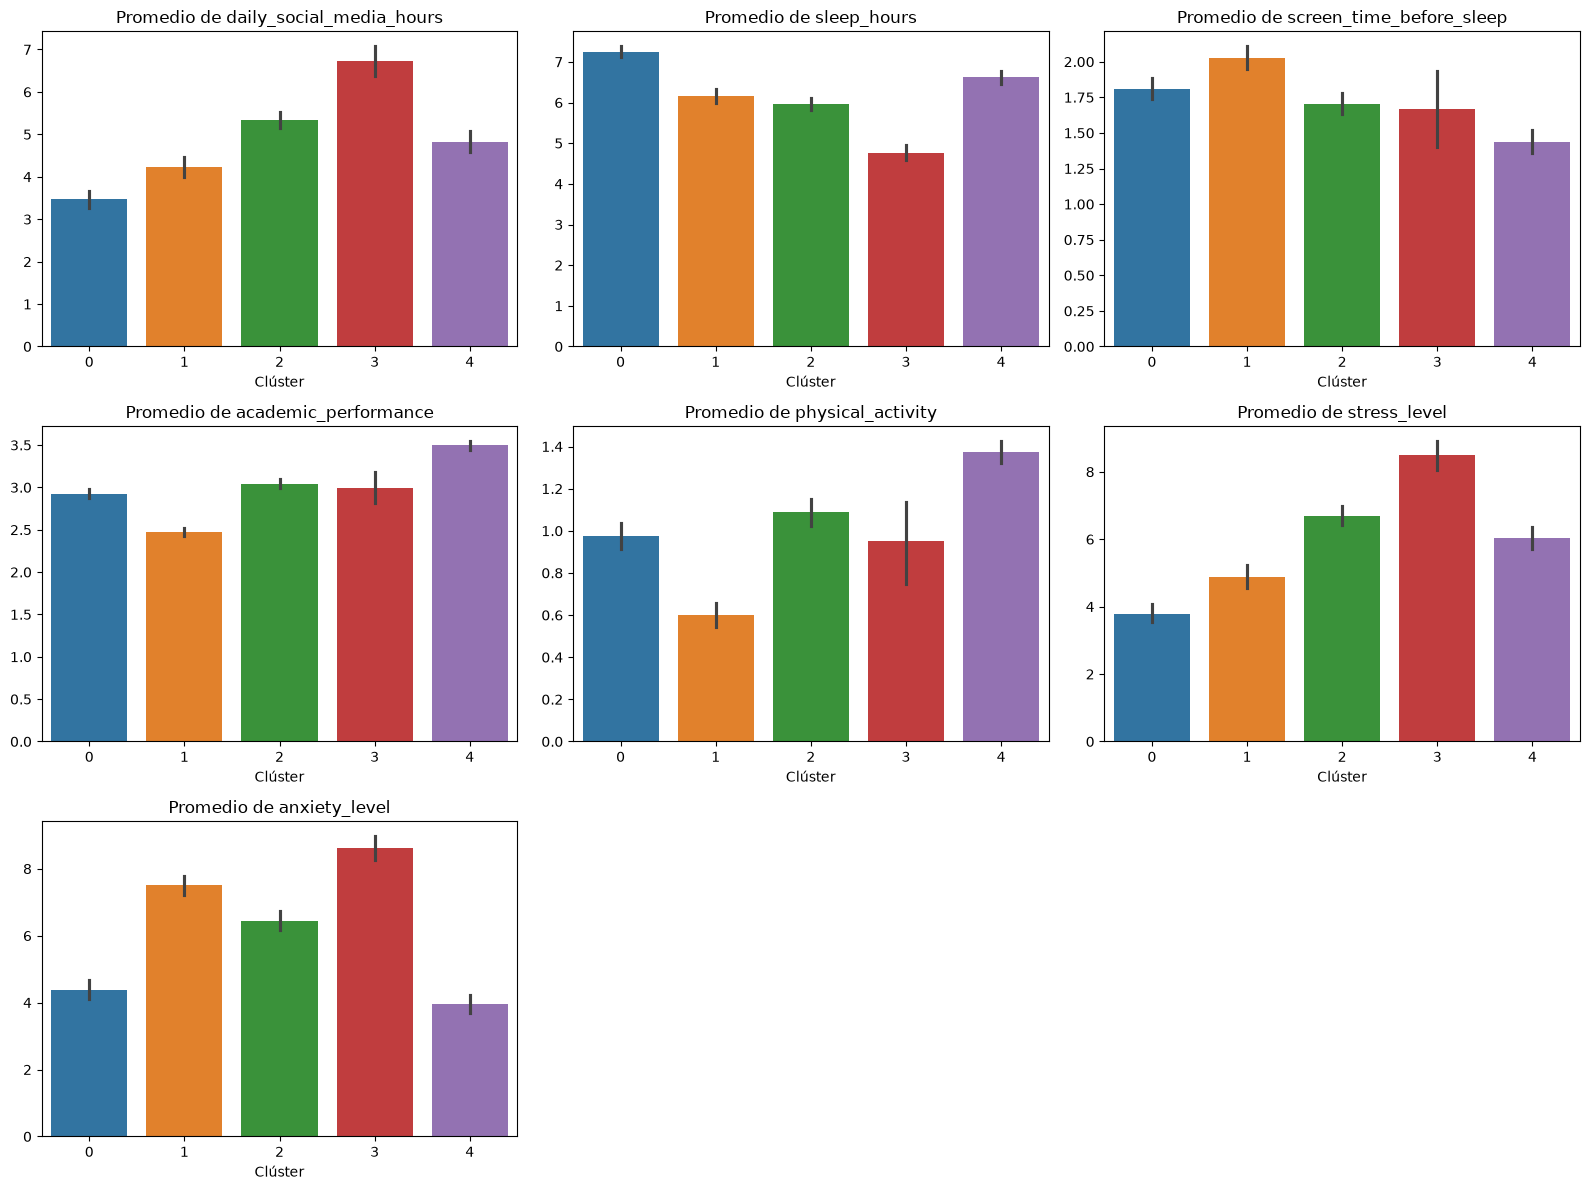

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# 1. Lista específica de columnas solicitadas
columnas_a_graficar = [
    'daily_social_media_hours', 
    'sleep_hours', 
    'screen_time_before_sleep', 
    'academic_performance', 
    'physical_activity', 
    'stress_level', 
    'anxiety_level'
]

# 2. Configurar la cuadrícula (3 gráficos por fila)
columnas_por_fila = 3
filas_necesarias = math.ceil(len(columnas_a_graficar) / columnas_por_fila)

fig, axes = plt.subplots(filas_necesarias, columnas_por_fila, figsize=(16, filas_necesarias * 4))
axes = axes.flatten()

# 3. Dibujar los gráficos de barras
for i, col in enumerate(columnas_a_graficar):
    sns.barplot(
        data=data_clusters, 
        x='Cluster', 
        y=col, 
        estimator='mean', 
        ax=axes[i],
        palette='tab10'
    )
    axes[i].set_title(f'Promedio de {col}', fontsize=12)
    axes[i].set_xlabel('Clúster')
    axes[i].set_ylabel('')

# 4. Ocultar los espacios vacíos sobrantes en la cuadrícula
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [13]:
from sklearn.cluster import DBSCAN

# Entrenar DBSCAN (debes ajustar eps y min_samples según tus datos)

dbscan = DBSCAN(eps=0.45, min_samples=4)
labels_dbscan = dbscan.fit_predict(data_pca)

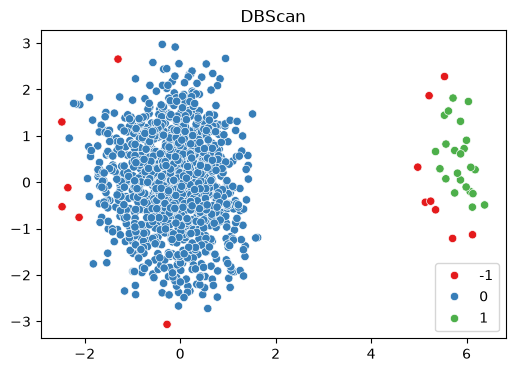

In [14]:
plt.figure(figsize=(6, 4))
plt.title("DBScan")
sns.scatterplot(x=data_pca[:, 0], y=data_pca[:, 1], hue=labels_dbscan, palette='Set1')
plt.show()

In [15]:
Clusters_dbscan = pd.DataFrame(labels_dbscan,columns=['Cluster'])
data_clusters_dbscan = data.merge(Clusters,left_index=True,right_index=True)

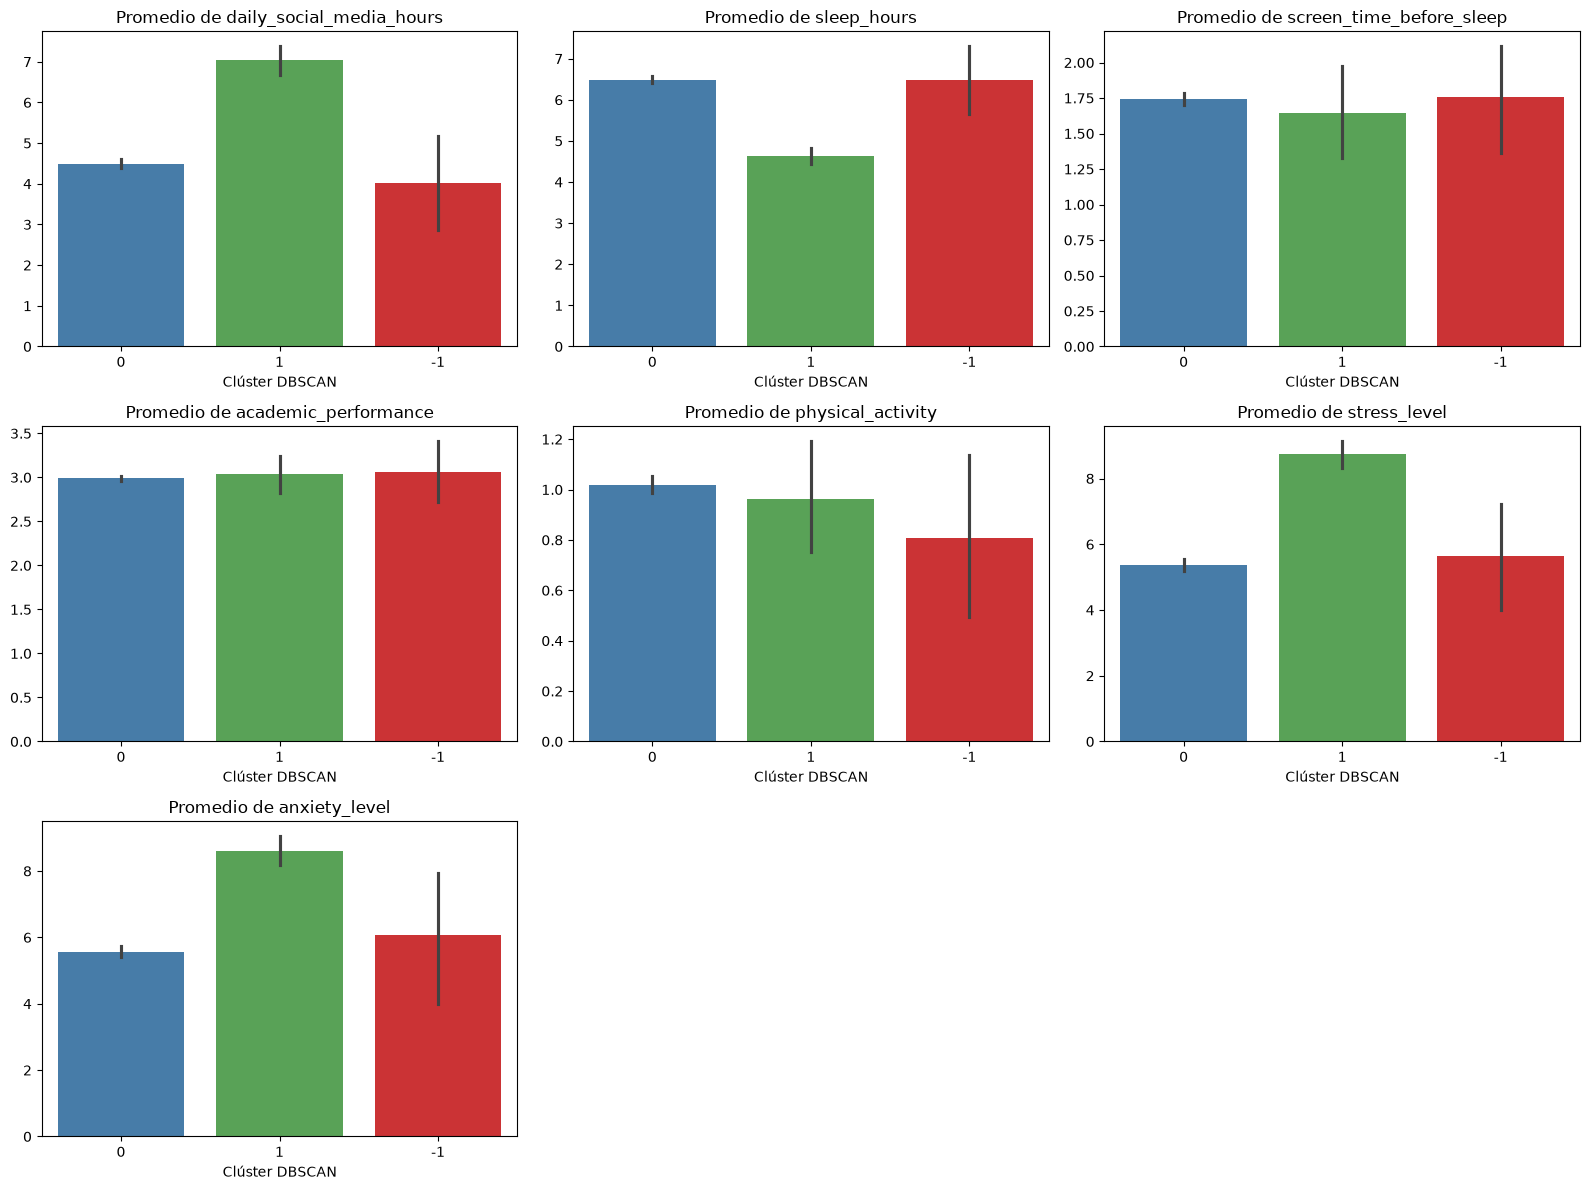

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# 1. Asegurar que las etiquetas de DBSCAN estén en tu DataFrame principal
data_clusters['Cluster_DBSCAN'] = labels_dbscan

# Convertimos la columna a tipo string (texto) para evitar problemas con la paleta
data_clusters['Cluster_DBSCAN'] = data_clusters['Cluster_DBSCAN'].astype(str)

# 2. Lista específica de tus 7 variables
columnas_a_graficar = [
    'daily_social_media_hours', 
    'sleep_hours', 
    'screen_time_before_sleep', 
    'academic_performance', 
    'physical_activity', 
    'stress_level', 
    'anxiety_level'
]

# 3. Configurar la cuadrícula (3 gráficos por fila)
columnas_por_fila = 3
filas_necesarias = math.ceil(len(columnas_a_graficar) / columnas_por_fila)

fig, axes = plt.subplots(filas_necesarias, columnas_por_fila, figsize=(16, filas_necesarias * 4))
axes = axes.flatten()

# 4. Paleta de colores personalizada con claves en formato Texto (String)
colores_dbscan = {'-1': '#e41a1c', '0': '#377eb8', '1': '#4daf4a'}

# 5. Dibujar los gráficos de barras
for i, col in enumerate(columnas_a_graficar):
    sns.barplot(
        data=data_clusters, 
        x='Cluster_DBSCAN', 
        y=col, 
        hue='Cluster_DBSCAN', # Forzamos a Seaborn a usar la columna para mapear los colores
        estimator='mean', 
        ax=axes[i],
        palette=colores_dbscan,
        legend=False # Ocultamos la leyenda individual para que no se sature el gráfico
    )
    axes[i].set_title(f'Promedio de {col}', fontsize=12)
    axes[i].set_xlabel('Clúster DBSCAN')
    axes[i].set_ylabel('')

# 6. Ocultar los espacios vacíos sobrantes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


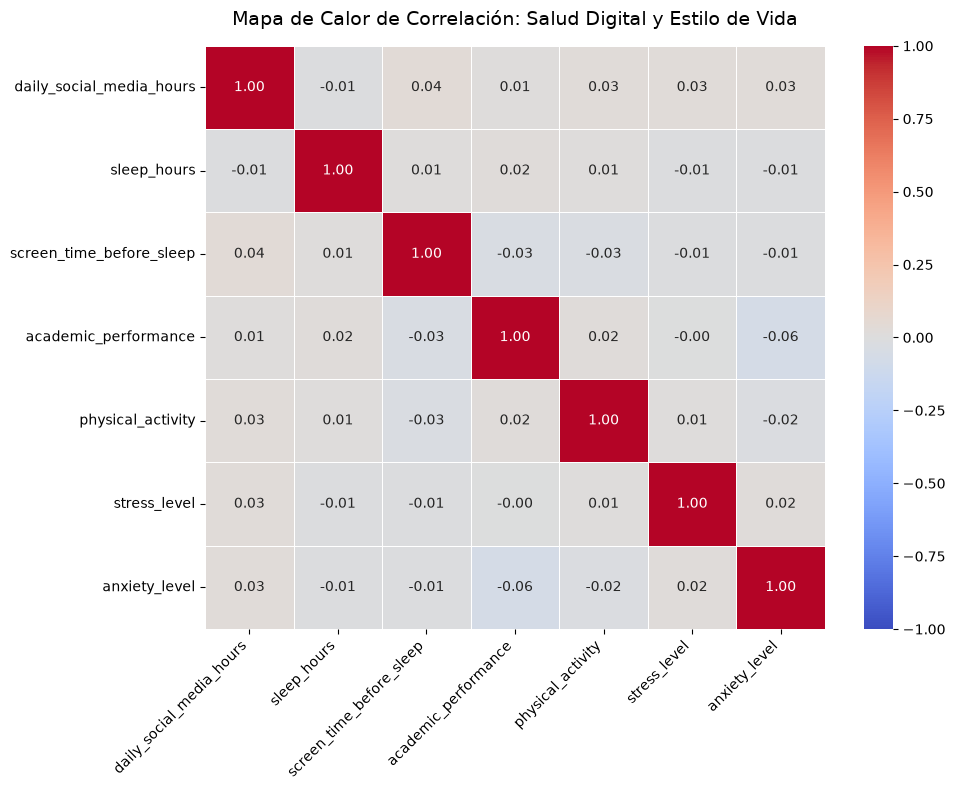

In [18]:

# 1. Definir la lista exacta de tus 7 variables
columnas_interes = [
    'daily_social_media_hours', 
    'sleep_hours', 
    'screen_time_before_sleep', 
    'academic_performance', 
    'physical_activity', 
    'stress_level', 
    'anxiety_level'
]

# 2. Calcular la matriz de correlación solo para esas columnas
# (Asegúrate de usar el nombre de tu DataFrame original, ej. data_clusters o data_limpia)
matriz_correlacion = data_clusters[columnas_interes].corr()

# 3. Configurar el tamaño de la figura
plt.figure(figsize=(10, 8))

# 4. Dibujar el mapa de calor
sns.heatmap(
    matriz_correlacion, 
    annot=True,          # Muestra los números exactos dentro de cada cuadro
    cmap='coolwarm',     # Paleta de azul (negativo) a rojo (positivo)
    fmt=".2f",           # Redondea los números a 2 decimales
    linewidths=0.5,      # Añade una línea sutil de separación entre cuadros
    vmin=-1, vmax=1      # Forzar la escala de -1 a 1
)

# 5. Configurar títulos y diseño
plt.title('Mapa de Calor de Correlación: Salud Digital y Estilo de Vida', fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right') # Rota los textos del eje X para que no se encimen
plt.tight_layout()

# 6. Mostrar el gráfico
plt.show()


 Analisis y Conclusiones

- El grupo que presenta menos estres y ansiedad, es tambien el que menos tiempo pasa en redes sociales, ademas de que tambien el que mas horas de sueño duerme.

- DE igual forma se puede evidenciar que los que presentan mayor nivel de estres y ansiedad, son tambien los que pasan mas tiempo en redes sociales y durmen mucho menos horas 

- No se evidencia una relacion entre el tiempo de pantalla antes de dormir y la cantidad de horas que duemen 

- Tampoco se evidencia con claridad que el tiempo en pantallas o el no dormir lo suficiente afecte sus estudios



| KMeans             | DBSCAN                 | 
| ------------------- | --------------------------- | 
| divide los datos de una forma mucho mas especifica, por eso salen mas grupos  | Agrupo los datos de una fromas mas aplia, por eso solos e generan 3 grupos |
| Todos los puntos se adicionan a un grupo, abligando a los valores atipicos el ser incluidos en alguno de los grupos  | toma los datos del cluster -1 como anormales, asi que filtra las anormalidades|


Podríamos concluir que el impacto de la tecnología sobre el bienestar estudiantil no es lineal ni evidente a simple vista; la salud mental permanece perfectamente estable hasta que el consumo digital supera las 7 horas diarias y el tiempo de descanso cae por debajo de las 5 horas. Al cruzar este límite crítico, se detona un perfil de riesgo donde los niveles de estrés y ansiedad se elevan drásticamente (cercanos a 9/10 puntos).
Finalmente, destaca el hallazgo de que este grupo en riesgo mantiene un buen rendimiento académico. Esto revela un sobreesfuerzo invisible, donde el alumno antepone sus estándares de desempeño a su propia salud biológica y emocional.